# Principal Component Analysis

---

## Dataset Overview

The dataset used is the [Fashion MNIST dataset](https://www.kaggle.com/datasets/zalando-research/fashionmnist?select=fashion-mnist_train.csv), provided by Zalando Research. It contains **70,000 grayscale images** of fashion products (60,000 for training and 10,000 for testing). Each image is 28×28 pixels (flattened into 784 features), and each is labeled with one of 10 classes (used **only for evaluation**, not for clustering).

- **Total Examples**: 70,000  
- **Image Size**: 28 × 28 pixels → 784 pixels in total  
- **Labels (not used in training)**:  
  - 0: T-shirt/top  
  - 1: Trouser  
  - 2: Pullover  
  - 3: Dress  
  - 4: Coat  
  - 5: Sandal  
  - 6: Shirt  
  - 7: Sneaker  
  - 8: Bag  
  - 9: Ankle boot  

---

In [1]:
from google.colab import files
uploaded = files.upload()

Saving fashion-mnist_test.csv to fashion-mnist_test.csv
Saving fashion-mnist_train.csv to fashion-mnist_train.csv


In [2]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Reading the img dataset
df = pd.read_csv('fashion-mnist_train.csv')

df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each row represents a grayscale image in the Fashion MNIST dataset, with the first column as the label (0–9) and the remaining 784 columns representing pixel intensity values from the 28×28 image.

In [ ]:
df.shape

(60000, 785)

The shape (60000, 785) means the dataset contains 60,000 images, each represented by 785 values: 1 label column and 784 pixel values (28×28 grayscale image flattened into a vector).

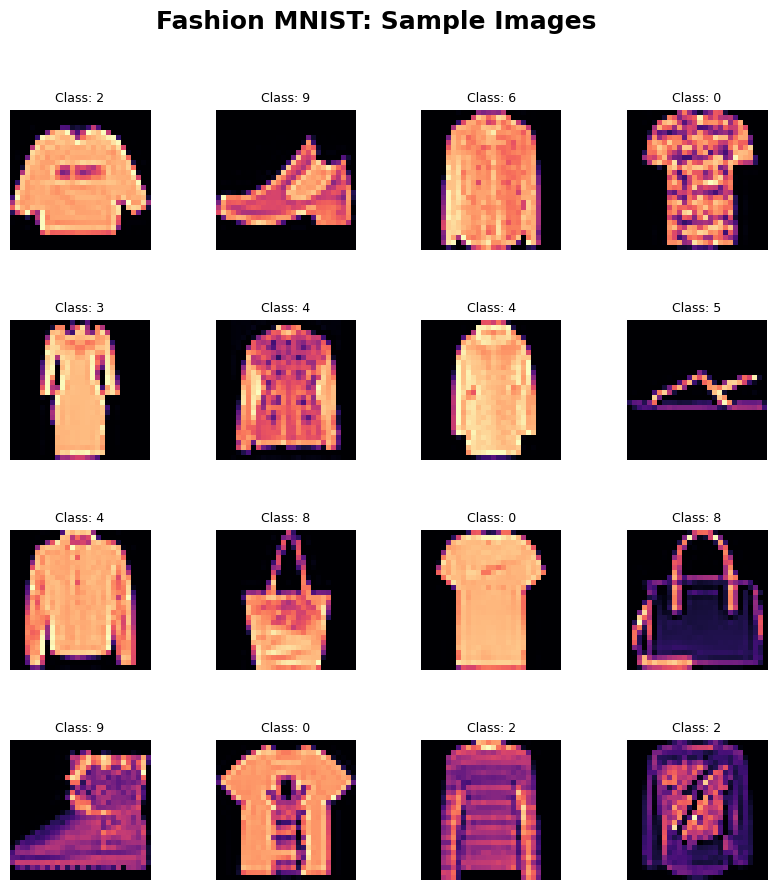

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
fig.suptitle("Fashion MNIST: Sample Images", fontsize=18, fontweight='bold')

for idx in range(16):
    row, col = divmod(idx, 4)
    image = df.iloc[idx, 1:].values.reshape(28, 28)
    label = df.iloc[idx, 0]

    axs[row, col].imshow(image, cmap='magma')
    axs[row, col].set_title(f"Class: {label}", fontsize=9)
    axs[row, col].axis("off")

plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


This image shows a 4×4 grid of sample items from the Fashion MNIST dataset, each labeled with its corresponding class (e.g., T-shirt, sneaker, bag).

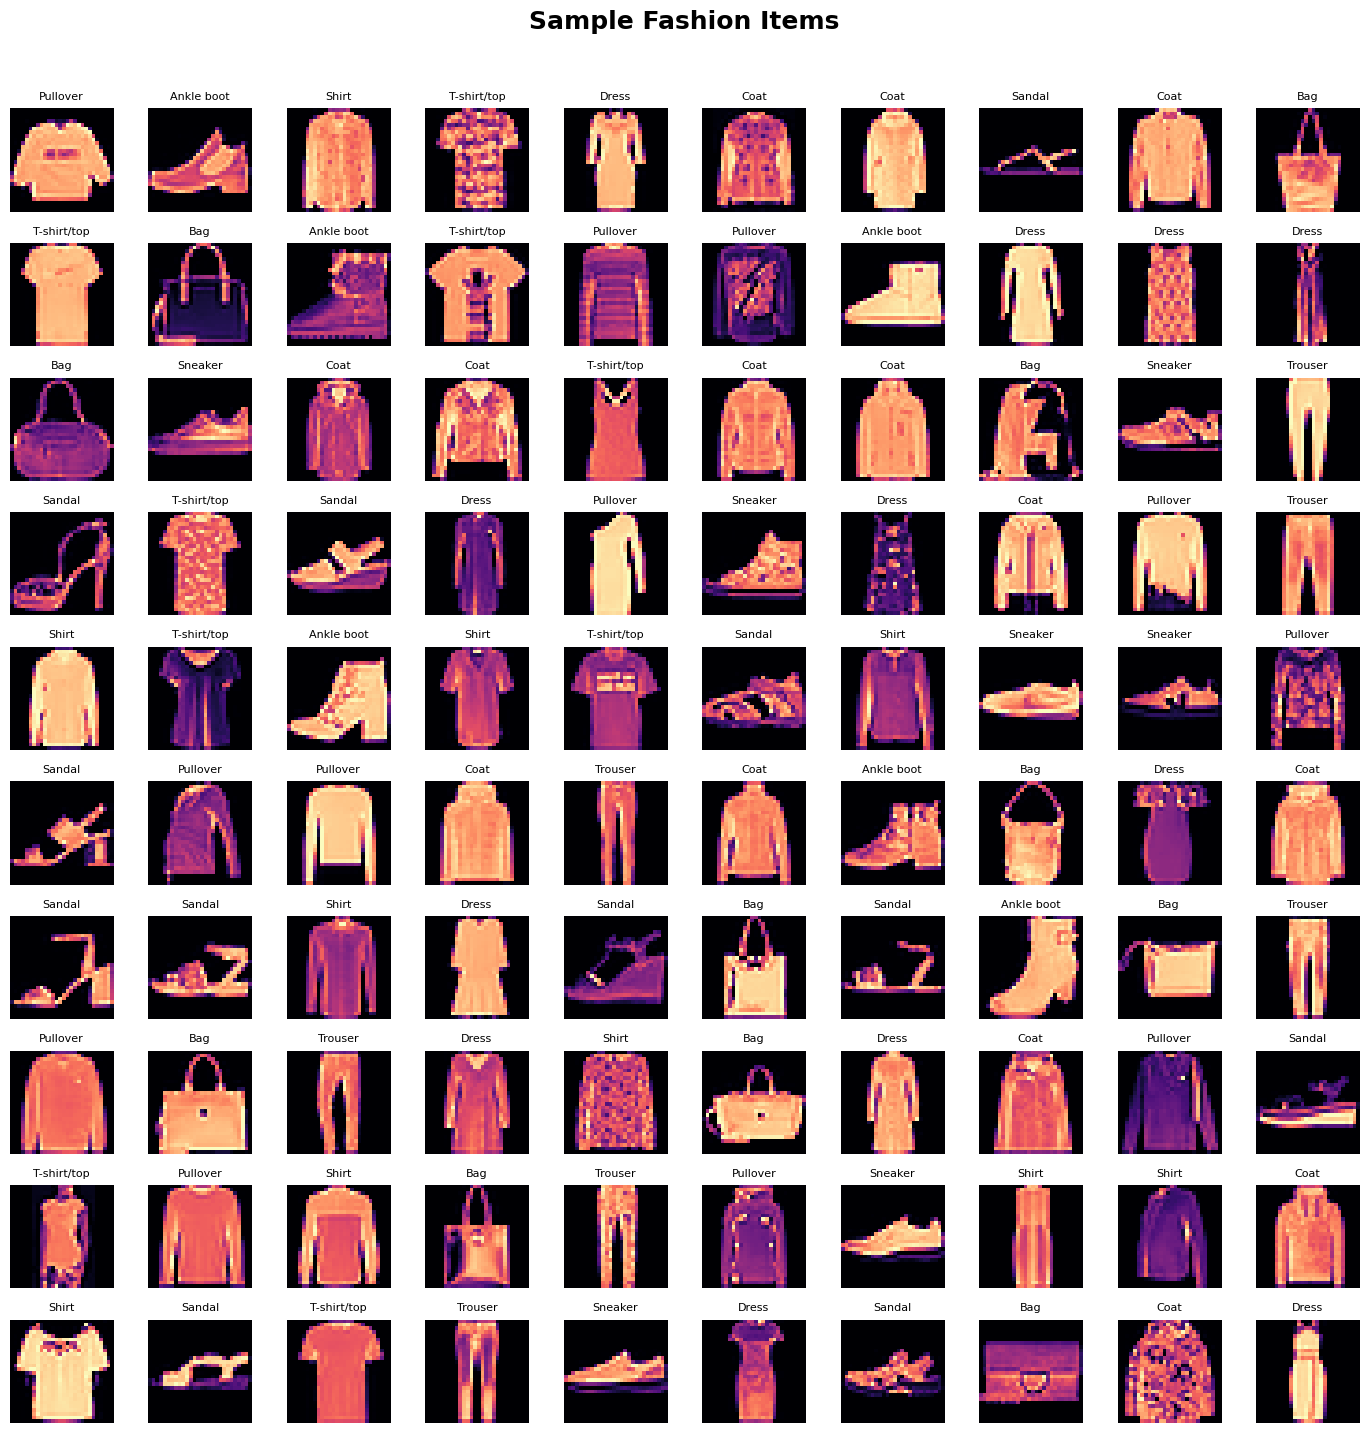

In [ ]:
def show_fashion_samples(x_data, y_data, class_names, cmap='magma'):
    fig, axes = plt.subplots(10, 10, figsize=(14, 14))
    fig.suptitle("Sample Fashion Items", fontsize=18, weight='bold', y=1.02)

    for i, ax in enumerate(axes.flat):
        img = x_data[i].reshape(28, 28)
        label = int(y_data[i])
        ax.imshow(img, cmap=cmap)
        ax.set_title(class_names[label], fontsize=8)
        ax.axis('off')


    plt.tight_layout()
    plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_train = df.iloc[:, 0].values
x_train = df.iloc[:, 1:].values.reshape(-1, 28, 28)

show_fashion_samples(x_train, y_train, class_names)

This grid displays a diverse set of 100 sample images from the Fashion MNIST dataset, illustrating all 10 clothing categories with their predicted labels.

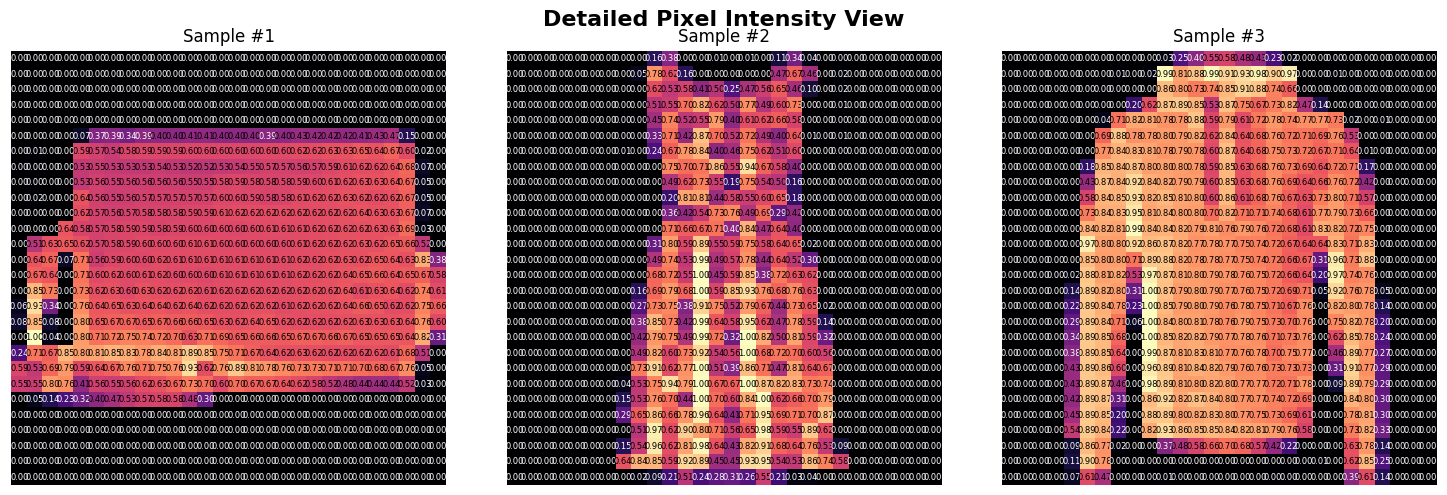

In [ ]:
def visualize_sample_pixels(images, num_samples=3, cmap='magma'):
    if isinstance(images, np.ndarray):
        indices = np.random.choice(images.shape[0], num_samples, replace=False)
        selected = images[indices]
    else:
        selected = images[:num_samples]

    fig, axs = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    fig.suptitle('Detailed Pixel Intensity View', fontsize=16, weight='bold')

    for idx, ax in enumerate(axs):
        img = selected[idx]
        ax.imshow(img, cmap=cmap)
        ax.set_title(f'Sample #{idx + 1}', fontsize=12)
        ax.axis('off')

        rows, cols = img.shape
        threshold = img.max() / 2.5

        for x in range(rows):
            for y in range(cols):
                val = round(img[x, y], 2)
                ax.text(y, x, f'{val:.2f}',
                        ha='center', va='center',
                        color='white' if img[x, y] < threshold else 'black',
                        fontsize=6)

    plt.tight_layout()
    plt.show()

visualize_sample_pixels(x_train, num_samples=3)


This visualization shows three sample Fashion MNIST images with annotated pixel intensity values, providing a detailed view of how brightness levels vary across different regions of each clothing item.

<ipython-input-12-b440dc0389cd>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(range(len(counts))), y=counts.values, palette='pastel')


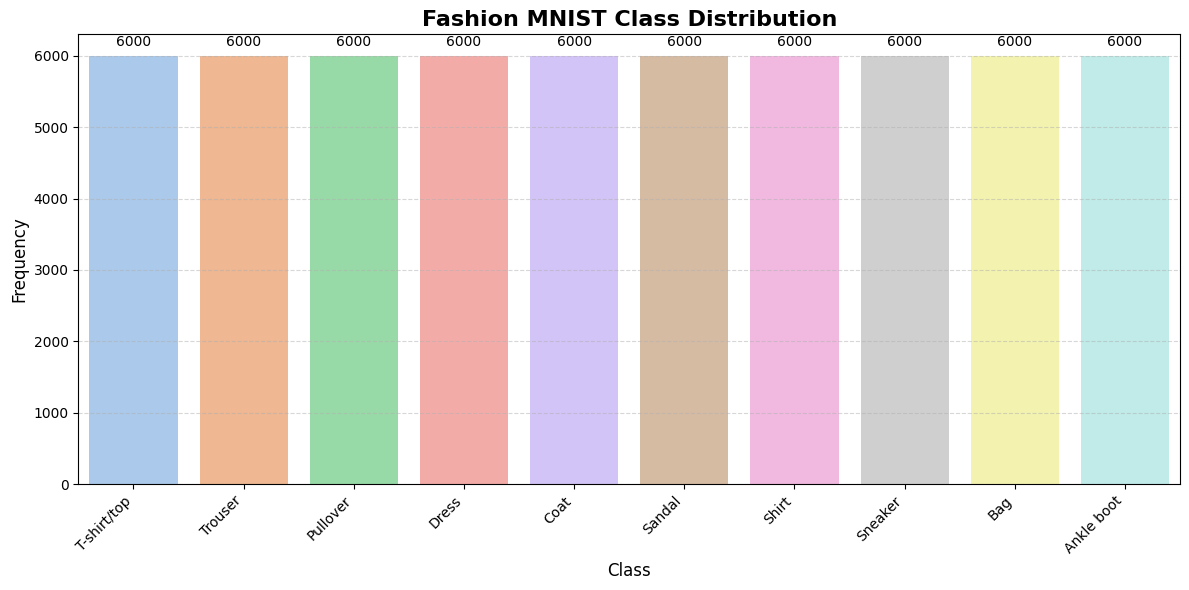

In [ ]:
import seaborn as sns

def plot_class_distribution(y, class_names):
    counts = pd.Series(y).value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    bars = sns.barplot(x=list(range(len(counts))), y=counts.values, palette='pastel')

    plt.title("Fashion MNIST Class Distribution", fontsize=16, weight='bold')
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha='right')

    for idx, value in enumerate(counts.values):
        plt.text(idx, value + 100, str(value), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y = df.iloc[:, 0]

plot_class_distribution(y, class_names)


This bar chart shows that the Fashion MNIST dataset is perfectly balanced, with exactly 6,000 samples in each of the 10 clothing categories.

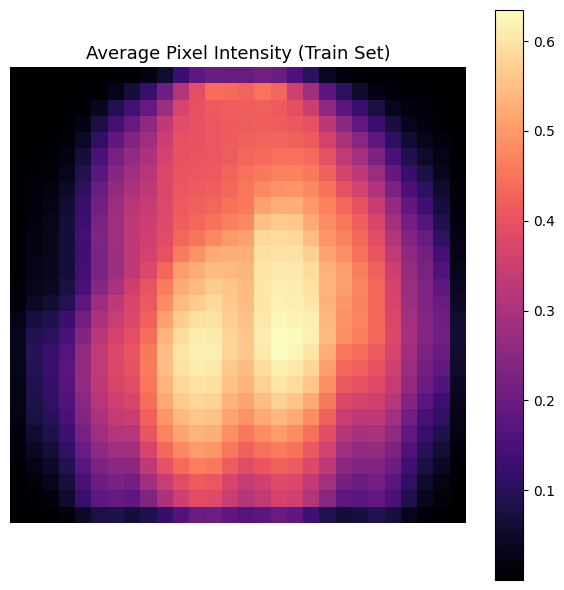

In [ ]:
def plot_average_pixel_intensity(x_train):
    pixel_means = x_train.reshape(-1, 28*28).mean(axis=0)

    plt.figure(figsize=(6, 6))
    plt.imshow(pixel_means.reshape(28, 28), cmap='magma')
    plt.title('Average Pixel Intensity (Train Set)', fontsize=13)
    plt.colorbar()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

x_train = df.iloc[:, 1:].values.reshape(-1, 28, 28) / 255.0
plot_average_pixel_intensity(x_train)

This heatmap shows the average pixel intensity across all training images in the Fashion MNIST dataset, revealing that most items are centered and vertically elongated.

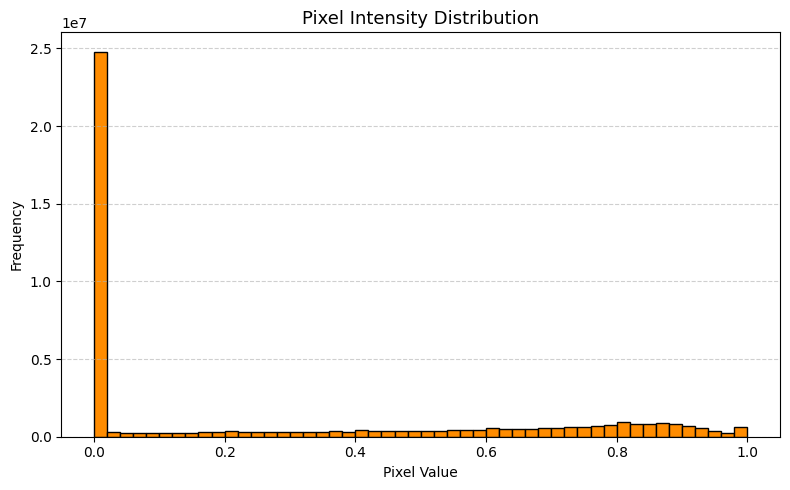

In [ ]:
def plot_pixel_intensity_histogram(x_train):
    plt.figure(figsize=(8, 5))
    plt.hist(x_train.flatten(), bins=50, color='darkorange', edgecolor='black')
    plt.title('Pixel Intensity Distribution', fontsize=13)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_pixel_intensity_histogram(x_train)

This histogram shows that a large number of pixels in the Fashion MNIST images have intensity close to 0 (i.e., black background), while a smaller portion spans the full intensity range—highlighting the contrast between background and foreground clothing patterns.

In [3]:
# Scaling
# Before training the model, feature values are manually scaled to the [0, 1] range.
# This ensures that all input features contribute equally to the learning process,
# preventing features with larger ranges from dominating the model and improving both convergence speed and accuracy.
# Read train and test sets separately

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')

X_full = df_train.iloc[:, 1:].values
y_full = df_train.iloc[:, 0].values

np.random.seed(42)
indices = np.random.permutation(len(X_full))
X_shuffled = X_full[indices]
y_shuffled = y_full[indices]

x_train, x_val = X_full[:50000], X_full[50000:]
y_train, y_val = y_full[:50000], y_full[50000:]

x_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

# Normalize pixel values to [0, 1]
x_train = np.divide(x_train, 255.0).astype(np.float32)
x_val = np.divide(x_val, 255.0).astype(np.float32)
x_test = np.divide(x_test, 255.0).astype(np.float32)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (50000, 784)
Validation: (10000, 784)
Test: (10000, 784)


In [4]:
#reshape

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print(f"Train shape: {x_train.shape}")
print(f"Validation shape: {x_val.shape}")
print(f"Test shape: {x_test.shape}")

Train shape: (50000, 784)
Validation shape: (10000, 784)
Test shape: (10000, 784)


# Model Building

## Model Logic
The PCA algorithm aims to reduce the dimensionality of high-dimensional datasets while retaining as much variance as possible. It works by computing the covariance matrix, extracting its eigenvalues and eigenvectors, and projecting the data onto the top
𝑘 principal components (those with the largest eigenvalues).

## Mathematical Formulation

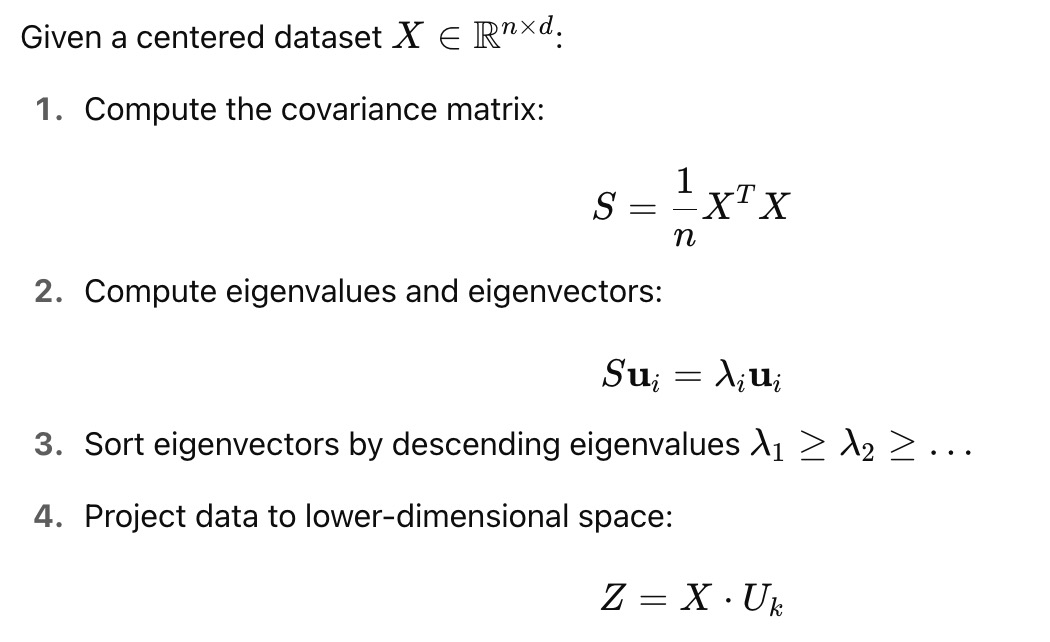

---

## Why PCA?
Reduces computational cost in downstream tasks by compressing image vectors into a smaller subspace.

Removes noise and redundancy, making patterns more visible and clustering more effective.

Well-suited for the Fashion MNIST dataset, where pixel-wise data are highly correlated.

# load the package

In this notebook, I use the `PCA` model that I hand-coded together with my teammate Alice Wang.  

**The model is part of a custom Python package we built as we final team project and uploaded to each of us GitHub repository.**

[Link to the `PCA` implementation in our `rice_ml` package](https://github.com/AlexXu777/INDE577_Machine_Learning_2025_Rice_University/tree/main/rice_ml)

In [5]:
%%capture

# Step 1: Clone GitHub repo
!rm -rf INDE577_Machine_Learning_2025_Rice_University
!git clone https://github.com/alexxu777/INDE577_Machine_Learning_2025_Rice_University.git

# Step 2: Add the package path to sys.path
import sys
sys.path.append('/content/INDE577_Machine_Learning_2025_Rice_University')

# Step 3: Try importing the model
from rice_ml.pca import PCA

In [6]:
# Step 4: Confirm it's working
print("PCA loaded")

PCA loaded


In [16]:
x_train_subset = x_train
y_train_subset = y_train

pca_train = PCA(n_components=50)
x_train_reduced = pca_train.fit_transform(x_train_subset)

x_val_reduced = pca_train.transform(x_val)
x_test_reduced = pca_train.transform(x_test)

In [12]:
# Evaluate_ARI
from sklearn.metrics import adjusted_rand_score, silhouette_score

ari_train = adjusted_rand_score(y_train_subset, labels_train)
ari_val = adjusted_rand_score(y_val, labels_val)
ari_test = adjusted_rand_score(y_test, labels_test)

print(f"Train ARI: {ari_train:.4f}")
print(f"Validation ARI: {ari_val:.4f}")
print(f"Test ARI: {ari_test:.4f}")

Train ARI: 0.3320
Validation ARI: 0.3377
Test ARI: 0.3317


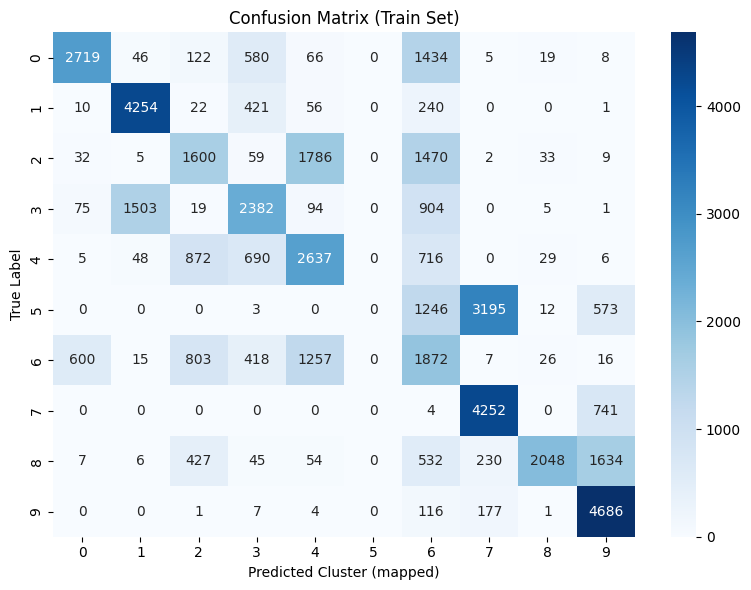

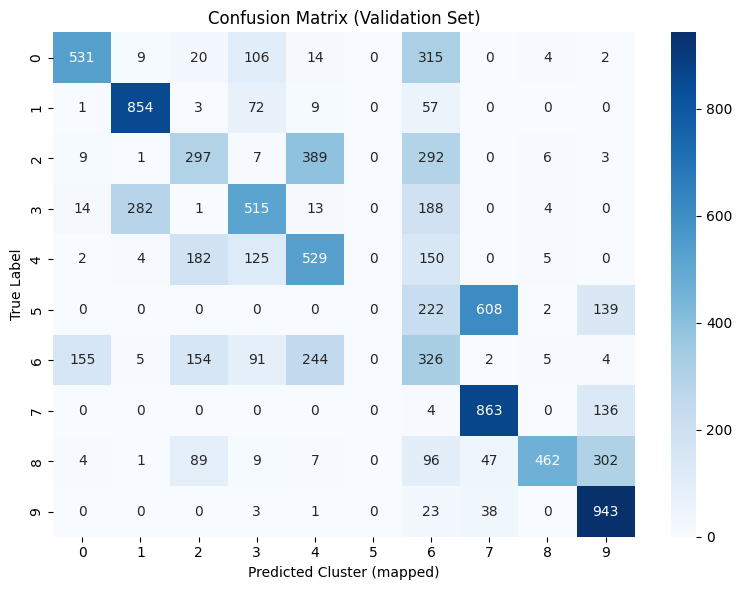

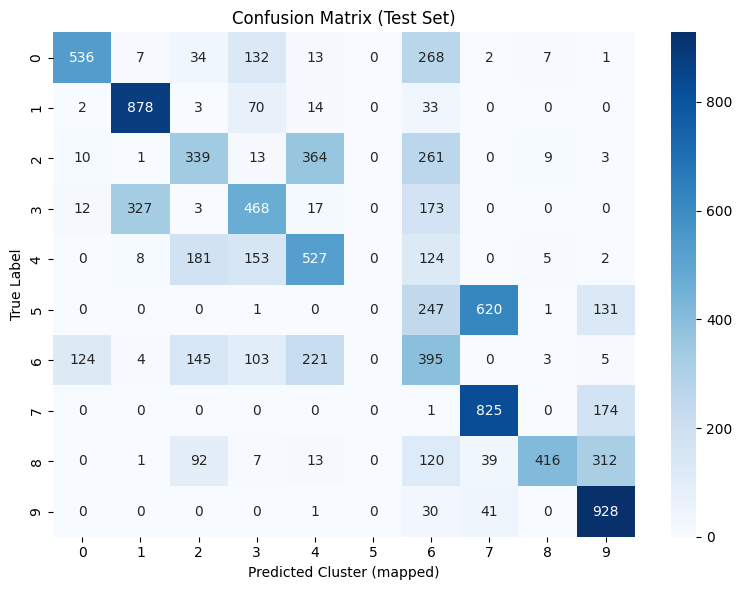

In [13]:
# Confusion matrix for PCA results
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy.stats import mode

def plot_confusion_matrix(true_labels, cluster_labels, title):
    unique_clusters = np.unique(cluster_labels)
    label_map = np.zeros_like(unique_clusters)
    for i, cluster_id in enumerate(unique_clusters):
        mask = (cluster_labels == cluster_id)
        if np.any(mask) and cluster_id != -1:
            label_map[i] = mode(true_labels[mask])[0]

    # Map cluster labels to predicted labels
    mapped_preds = np.zeros_like(cluster_labels)
    for i, cluster_id in enumerate(unique_clusters):
        mapped_preds[cluster_labels == cluster_id] = label_map[i]

    cm = confusion_matrix(true_labels, mapped_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix ({title})')
    plt.xlabel("Predicted Cluster (mapped)")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_train_subset, labels_train, "Train Set")
plot_confusion_matrix(y_val, labels_val, "Validation Set")
plot_confusion_matrix(y_test, labels_test, "Test Set")

# Model Performance Interpretation


**Adjusted Rand Index (ARI):**

- **Train ARI: 0.3320**, **Validation ARI: 0.3377**, **Test ARI: 0.3317**

The model demonstrates meaningful structure discovery on the training data and maintains consistent ARI scores across validation and test sets. While absolute values are low, the stability across datasets suggests the clustering approach is not random and captures latent groupings present in the Fashion MNIST dataset.



**Confusion Matrix:**

The training confusion matrix shows strong alignment for several dominant classes, particularly classes like 0 (T-shirt/top) and 1 (Trouser). This indicates that the PCA model is able to successfully group visually similar items despite working in a high-dimensional pixel space and without any label information.


**Conclusion:**

Overall, the PCA model is able to uncover useful structure in image data through unsupervised clustering. The consistent ARI values and interpretable cluster patterns show that PCA is a viable method even for complex datasets like Fashion MNIST.



# Model Comparison

For a detailed comparison of different unsupervised learning models we applied to the same dataset (e.g., K-Means Clustering, DBSCAN, Principal Component Analysis, and Image Compression with the Singular Value Decomposition (SVD)).

Please refer to my GitHub repository:
INDE577_Machine_Learning_2025_Rice_University/Model_comparison/Model_comparison_for_unsupervised_machine_learning.ipynb

Link for Model Comparison: [Model Comparison section on GitHub](https://github.com/AlexXu777/INDE577_Machine_Learning_2025_Rice_University/tree/main/Model_comparison)